# Practice Lab: Regularization with Ridge, Lasso, and ElasticNet

We are tackling a common problem in Data Science: **Multicollinearity** (when your features are highly correlated with each other) and **Overfitting**. 

To solve this, we will use **Regularization**, which penalizes complex models. You will build and compare four models:
1. Standard Linear Regression (Base Model)
2. Ridge Regression ($L_2$ Penalty)
3. Lasso Regression ($L_1$ Penalty)
4. ElasticNet (Combination of $L_1$ and $L_2$)

### Abalone & The Business Problem
We will use the famous Abalone dataset to predict the age of an abalone (a highly valued marine snail) based on its physical measurements. 

**Why does predicting their age matter?**

Abalones are a premium seafood delicacy, making them vulnerable to overfishing. Strict regulations are in place to ensure abalones are only harvested after they reach a certain age, allowing them time to reproduce. Furthermore, aquaculture farms need to track age to optimize feeding and harvest times for profit. 

Currently, determining an abalone's age is a destructive, expensive, and tedious process: it requires cutting the shell, staining it, and counting the rings under a microscope. **Our goal is to build a Machine Learning model that can predict the age (number of rings) using simple, non-destructive measurements like weight and length.** If successful, we can save fisheries time and money!

**Data Dictionary:**
|Column| Definition |
|------|------------|
|`Sex`|: M (Male), F (Female), I (Infant)|
|`Length`|: Longest shell measurement (mm)|
|`Diameter`|: Perpendicular to length (mm)|
|`Height`|: With meat in shell (mm)|
|`Whole_weight`|: Whole abalone (grams)|
|`Shucked_weight`|: Weight of meat (grams)|
|`Viscera_weight`|: Gut weight after bleeding (grams)|
|`Shell_weight`|: After being dried (grams)|
|`Class` (Target)|: Number of rings. *Note: Age is roughly rings + 1.5 years.*|

In [1]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score

from sklearn.linear_model import LinearRegression, RidgeCV, LassoCV, ElasticNetCV

# Ignore warnings for cleaner output
import warnings
warnings.filterwarnings('ignore')

## 1. Load the Data
We will fetch the Abalone dataset directly from OpenML.

In [2]:
# Fetch Abalone dataset (version 1)
abalone = fetch_openml(name="abalone", version=1, as_frame=True, parser='auto')
df = abalone.frame

# Rename the target column from 'Class' to 'Rings' for clarity
df = df.rename(columns={'Class_number_of_rings': 'Rings'})

# Display the first 5 rows
df.head()

,Sex,Length,Diameter,Height,Whole_weight,Shucked_weight,Viscera_weight,Shell_weight,Rings
0,M,0.455,0.365,0.095,0.5140,0.2245,0.1010,0.150,15
1,M,0.350,0.265,0.090,0.2255,0.0995,0.0485,0.070,7
2,F,0.530,0.420,0.135,0.6770,0.2565,0.1415,0.210,9
3,M,0.440,0.365,0.125,0.5160,0.2155,0.1140,0.155,10
4,I,0.330,0.255,0.080,0.2050,0.0895,0.0395,0.055,7


## 2. Exploratory Data Analysis (EDA)
Before modeling, let's understand our data. Regularization is especially useful when features are highly correlated. Let's prove that this dataset has high multicollinearity.

In [11]:
# TODO: Create a correlation matrix for the NUMERICAL features only.
# and NOTE down your observation!
# Hint: Drop the 'Sex' column temporarily or select only numeric columns.
# Optional but recommended: Plot this using sns.heatmap()


In [3]:
# TODO: Check for missing values in the dataframe
df.isnull().sum()

Sex               0
Length            0
Diameter          0
Height            0
Whole_weight      0
Shucked_weight    0
Viscera_weight    0
Shell_weight      0
Rings             0
dtype: int64

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4177 entries, 0 to 4176
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype   
---  ------          --------------  -----   
 0   Sex             4177 non-null   category
 1   Length          4177 non-null   float64 
 2   Diameter        4177 non-null   float64 
 3   Height          4177 non-null   float64 
 4   Whole_weight    4177 non-null   float64 
 5   Shucked_weight  4177 non-null   float64 
 6   Viscera_weight  4177 non-null   float64 
 7   Shell_weight    4177 non-null   float64 
 8   Rings           4177 non-null   category
dtypes: category(2), float64(7)
memory usage: 238.1 KB


In [5]:
df.describe()

,Length,Diameter,Height,Whole_weight,Shucked_weight,Viscera_weight,Shell_weight
count,4177.000000,4177.000000,4177.000000,4177.000000,4177.000000,4177.000000,4177.000000
mean,0.523992,0.407881,0.139516,0.828742,0.359367,0.180594,0.238831
std,0.120093,0.099240,0.041827,0.490389,0.221963,0.109614,0.139203
min,0.075000,0.055000,0.000000,0.002000,0.001000,0.000500,0.001500
25%,0.450000,0.350000,0.115000,0.441500,0.186000,0.093500,0.130000
50%,0.545000,0.425000,0.140000,0.799500,0.336000,0.171000,0.234000
75%,0.615000,0.480000,0.165000,1.153000,0.502000,0.253000,0.329000
max,0.815000,0.650000,1.130000,2.825500,1.488000,0.760000,1.005000


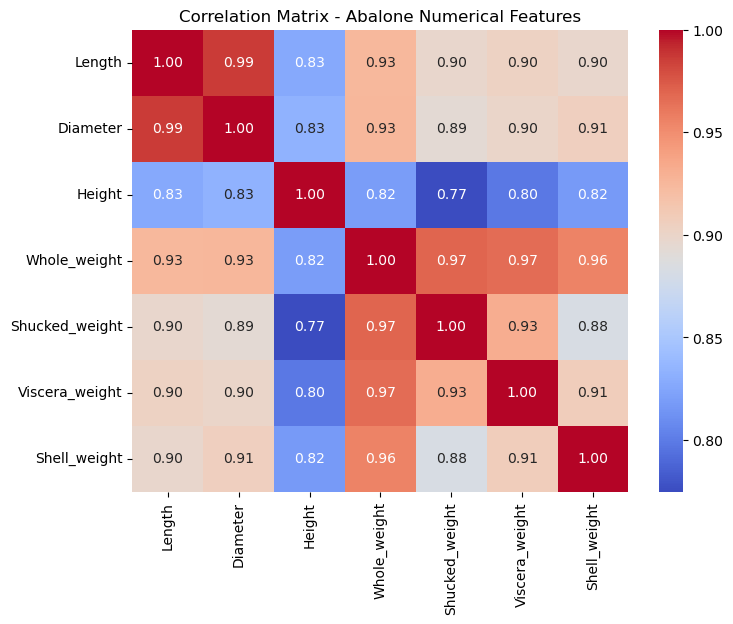

,Length,Diameter,Height,Whole_weight,Shucked_weight,Viscera_weight,Shell_weight
Length,1.000000,0.986812,0.827554,0.925261,0.897914,0.903018,0.897706
Diameter,0.986812,1.000000,0.833684,0.925452,0.893162,0.899724,0.905330
Height,0.827554,0.833684,1.000000,0.819221,0.774972,0.798319,0.817338
Whole_weight,0.925261,0.925452,0.819221,1.000000,0.969405,0.966375,0.955355
Shucked_weight,0.897914,0.893162,0.774972,0.969405,1.000000,0.931961,0.882617
Viscera_weight,0.903018,0.899724,0.798319,0.966375,0.931961,1.000000,0.907656
Shell_weight,0.897706,0.905330,0.817338,0.955355,0.882617,0.907656,1.000000


In [6]:
numeric_df = df.select_dtypes(include=[np.number])
corr_matrix = numeric_df.corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Matrix - Abalone Numerical Features")
plt.show()

corr_matrix

## 3. Data Preprocessing
Machine Learning models need numbers, not text. We need to handle the categorical `Sex` column and split our data. 

**Crucial Note for Regularization:** You MUST scale your features when using Ridge, Lasso, or ElasticNet. Because regularization penalizes the size of the coefficients, features on larger scales (like thousands) will be penalized unfairly compared to features on smaller scales (like decimals) if they aren't standardized first.

In [7]:
# TODO: One-hot encode the 'Sex' column using pd.get_dummies() or One-hot Encoding. 
# Hint: Use drop_first=True to avoid the dummy variable trap.
df_encoded = pd.get_dummies(df, columns=['Sex'], drop_first=True)
df_encoded.head()

,Length,Diameter,Height,Whole_weight,Shucked_weight,Viscera_weight,Shell_weight,Rings,Sex_I,Sex_M
0,0.455,0.365,0.095,0.5140,0.2245,0.1010,0.150,15,False,True
1,0.350,0.265,0.090,0.2255,0.0995,0.0485,0.070,7,False,True
2,0.530,0.420,0.135,0.6770,0.2565,0.1415,0.210,9,False,False
3,0.440,0.365,0.125,0.5160,0.2155,0.1140,0.155,10,False,True
4,0.330,0.255,0.080,0.2050,0.0895,0.0395,0.055,7,True,False


In [8]:
# TODO: Separate your features (X) and target (y)

X = df_encoded.drop(columns=['Rings'])
y = df_encoded['Rings']

In [9]:
# TODO: Perform a train_test_split. Use a test_size of 0.2 and random_state of 10.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=10)

In [10]:
# TODO: Initialize the StandardScaler
scaler = StandardScaler()
# TODO: Fit the scaler on the training data AND transform X_train. 
X_train_scaled = scaler.fit_transform(X_train)
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)


# TODO: Transform the test data (Do NOT fit the scaler on the test data!)
X_test_scaled = scaler.transform(X_test)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns, index=X_test.index)

## 4. Don't Repeat Yourself (DRY): Evaluation Function
As good programmers, we want to avoid writing the same evaluation code four times. 

Write a function that takes in a fitted model, the training data, and the testing data, and prints out the $R^2$ and Root Mean Squared Error (RMSE) for BOTH the training and test sets. Comparing train vs. test metrics helps us spot overfitting!

*__Note__: You can add this to your go-to function toolbox!*

In [22]:
import numpy as np
from sklearn.metrics import r2_score, mean_squared_error

def evaluate_model(model, X_train, X_test, y_train, y_test, model_name="Model"):
    """
    Predicts and calculates R2 and RMSE for both train and test sets.
    Then prints the Train R2 and RMSE along with the Test R2 and RMSE
    """
    print(f"--- {model_name} Performance ---")
    
    # Generate predictions for both X_train and X_test
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)
    
    # Calculate R2 for train and test
    train_r2 = r2_score(y_train, y_train_pred)
    test_r2 = r2_score(y_test, y_test_pred)
    
    # Calculate RMSE for train and test
    train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
    test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
    
    # Print the results clearly
    print(f"Train R2: {train_r2:.4f}  |  Train RMSE: {train_rmse:.4f}")
    print(f"Test  R2: {test_r2:.4f}  |  Test  RMSE: {test_rmse:.4f}")

## 5. Base Model: Standard Linear Regression
Let's see how a standard linear regression model handles this highly correlated data.

In [26]:
# TODO: Initialize and fit a standard Linear Regression model on the SCALED training data
y_train = y_train.astype(float)
y_test = y_test.astype(float)
lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)

# TODO: Use your custom evaluate_model() function to check its performance
evaluate_model(lr_model, X_train_scaled, X_test_scaled, y_train, y_test, "Linear Regression")

--- Linear Regression Performance ---
Train R2: 0.5349  |  Train RMSE: 2.2113
Test  R2: 0.5497  |  Test  RMSE: 2.1116


## 6. Regularization Models
Now, let's apply penalties to our model to handle the multicollinearity.

Instead of guessing the penalty term (`alpha`), we will use Scikit-Learn's built-in Cross-Validation models (`RidgeCV`, `LassoCV`, `ElasticNetCV`). These models automatically try a list of different alphas and select the one that performs best!

### RIDGE REGRESSION (L2 Penalty)

In [27]:
# We provide a list of alphas to test (from very small to very large)
alphas_to_test = [0.01, 0.1, 1.0, 10.0, 100.0]

# TODO: Initialize RidgeCV with the alphas_to_test, cv=5, random_state=10 and fit it to the training data
ridge_model = RidgeCV(alphas=alphas_to_test, cv=5)
ridge_model.fit(X_train_scaled, y_train)

# TODO: Use evaluate_model() to check performance
evaluate_model(ridge_model, X_train_scaled, X_test_scaled, y_train, y_test, "Ridge Regression")

# TODO: Print the best alpha found by RidgeCV (Hint: look up the .alpha_ attribute)
print("Best alpha (Ridge):", ridge_model.alpha_)

--- Ridge Regression Performance ---
Train R2: 0.5349  |  Train RMSE: 2.2114
Test  R2: 0.5497  |  Test  RMSE: 2.1118
Best alpha (Ridge): 1.0


### LASSO REGRESSION (L1 Penalty)

__Note__: You can provide a custom list to `LassoCV` and `ElasticNetCV` if you want to, but it is generally best practice to leave it blank and let Scikit-Learn automatically calculate the optimal path for you.

In [28]:
# TODO: Initialize LassoCV (you can let it choose alphas automatically by not passing any), cv=5, random_state=10 
# and fit it to the training data
lasso_model = LassoCV(cv=5, random_state=10)
lasso_model.fit(X_train_scaled, y_train)

# TODO: Use evaluate_model() to check performance
evaluate_model(lasso_model, X_train_scaled, X_test_scaled, y_train, y_test, "Lasso Regression")

# TODO: Print the best alpha found by LassoCV
print("Best alpha (Lasso):", lasso_model.alpha_)

--- Lasso Regression Performance ---
Train R2: 0.5347  |  Train RMSE: 2.2118
Test  R2: 0.5493  |  Test  RMSE: 2.1126
Best alpha (Lasso): 0.003102557702171799


### ELASTICNET REGRESSION (L1 + L2 Penalty)

In [29]:
# TODO: Initialize ElasticNetCV with cv=5, random_state=10 and fit it to the training data
elasticnet_model = ElasticNetCV(cv=5, random_state=10)
elasticnet_model.fit(X_train_scaled, y_train)

# TODO: Use evaluate_model() to check performance
evaluate_model(elasticnet_model, X_train_scaled, X_test_scaled, y_train, y_test, "ElasticNet Regression")

# TODO: Print the best alpha found by ElasticNetCV
print("Best alpha (ElasticNet):", elasticnet_model.alpha_)

--- ElasticNet Regression Performance ---
Train R2: 0.5335  |  Train RMSE: 2.2148
Test  R2: 0.5480  |  Test  RMSE: 2.1156
Best alpha (ElasticNet): 0.004082551587352136


## 7. Feature Selection with Lasso
One of the superpower traits of Lasso ($L_1$ regularization) is that it can shrink the coefficients of useless or highly correlated features down to **exactly zero**. This acts as automatic feature selection.

Let's look at the coefficients of our models to see this in action.

In [30]:
# Provided Code: Run this cell to compare coefficients!
coef_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Linear_Coef': lr_model.coef_,       # Update 'lr_model' if you named your Linear Regression variable differently
    'Ridge_Coef': ridge_model.coef_,     # Update 'ridge_model' if needed
    'Lasso_Coef': lasso_model.coef_,      # Update 'lasso_model' if needed
    'ElasticNet_Coef': elasticnet_model.coef_
})

# Display the coefficients
coef_df.round(3)

,Feature,Linear_Coef,Ridge_Coef,Lasso_Coef,ElasticNet_Coef
0,Length,0.020,0.025,0.000,0.029
1,Diameter,0.984,0.976,0.981,0.942
2,Height,0.440,0.441,0.437,0.442
3,Whole_weight,4.385,4.202,3.955,3.161
4,Shucked_weight,-4.370,-4.283,-4.168,-3.776
5,Viscera_weight,-1.125,-1.083,-0.987,-0.817
6,Shell_weight,1.254,1.315,1.382,1.640
7,Sex_I,-0.388,-0.390,-0.389,-0.396
8,Sex_M,0.012,0.012,0.008,0.006


__Q1. Which feature(s) did Lasso completely drop (set to 0)?__ 

__Answer:__ Length



__Q2. How does ElasticNet compare to Lasso and Ridge here?__

__Answer:__ ElasticNet sits in between the two: like Ridge, it shrinks all coefficients smoothly rather than zeroing them out completely (e.g. Length shrinks to 0.029 instead of exactly 0), but like Lasso, it still applies a meaningful L1 penalty that pulls the large, correlated weight coefficients (Whole_weight, Shucked_weight) down more aggressively than Ridge does. In this dataset, since Lasso only zeroed out one weakly-informative feature, ElasticNet doesn't show a dramatic advantage over either — but it offers a good middle ground: some of Lasso's ability to shrink redundant features plus Ridge's stability when features are highly collinear.




## 8. Communicating Results to Stakeholders

**Scenario:** 
Imagine you are presenting these findings to the manager of a seafood fishery. They have no background in data science or math. They want to know if they can trust this model to replace the manual, time-consuming process of cutting abalone shells and counting rings under a microscope. 

**How to phrase your answer:**
When speaking to stakeholders, avoid throwing raw math at them. Translate the metrics into real-world impact. 

*Example using a Real Estate Model:*
*   ❌ **Bad:** "The model has an RMSE of 25000 and an $R^2$ of 0.85."
*   ✅ **Good:** "Our model is highly accurate, capturing about 85% of the factors that drive house prices. When it makes a prediction, it is typically off by about $25,000 on average."

**Your Task:**
Double-click this text cell. Based on your best model's RMSE and $R^2$ scores, write a 3-4 sentence explanation answering the fishery manager's question. Be honest about whether the model is accurate enough to replace humans entirely, or if it should just be used as an estimation tool.
> *# TODO: Write your explanation for the Fishery Manager here...*
>  Our model, based on simple measurements like weight and length, can explain roughly 55% of what drives an abalone's age (rings). On average, our age predictions are off by about 2 rings (roughly 2 years), which is useful for a quick estimate but not perfectly precise. Because of this, I would not recommend fully replacing the manual ring-counting process just yet, especially in cases requiring exact age (like verifying strict legal harvest thresholds). Instead, this model works best as a fast, non-destructive screening tool: it can quickly flag abalones that are clearly too young to harvest or clearly mature enough, saving time and only reserving the manual, more expensive shell-cutting method for the ages that are borderline or that require legal certification

# Now it’s your turn!
1. Derive at least one new feature that adds value to the dataset.
2. Apply a feature selection technique to eliminate uninformative variables.
3. Document your reasoning in clean Markdown cells as you go!

In [33]:
df_encoded['Meat_Yield_Ratio'] = df_encoded['Shucked_weight'] / df_encoded['Whole_weight']

X2 = df_encoded.drop(columns=['Rings'])

y2 = df_encoded['Rings'].astype(float)

X2_train, X2_test, y2_train, y2_test = train_test_split(X2, y2, test_size=0.2, random_state=10)

scaler2 = StandardScaler()
X2_train_scaled = pd.DataFrame(scaler2.fit_transform(X2_train), columns=X2_train.columns, index=X2_train.index)
X2_test_scaled = pd.DataFrame(scaler2.transform(X2_test), columns=X2_test.columns, index=X2_test.index)

# --- Feature Selection using Lasso ---
lasso_fs = LassoCV(cv=5, random_state=10)
lasso_fs.fit(X2_train_scaled, y2_train)

evaluate_model(lasso_fs, X2_train_scaled, X2_test_scaled, y2_train, y2_test, "Lasso with Meat_Yield_Ratio")

fs_coef_df = pd.DataFrame({
    'Feature': X2_train.columns,
    'Lasso_Coef': lasso_fs.coef_
}).sort_values('Lasso_Coef', key=abs, ascending=False)

print(fs_coef_df.round(3))

# Keep only the non-zero (selected) features
selected_features = fs_coef_df.loc[fs_coef_df['Lasso_Coef'] != 0, 'Feature'].tolist()
print("\nSelected features:", selected_features)

--- Lasso with Meat_Yield_Ratio Performance ---
Train R2: 0.5348  |  Train RMSE: 2.2115
Test  R2: 0.5476  |  Test  RMSE: 2.1167
            Feature  Lasso_Coef
4    Shucked_weight      -4.157
3      Whole_weight       4.013
6      Shell_weight       1.348
5    Viscera_weight      -1.032
1          Diameter       0.991
2            Height       0.438
7             Sex_I      -0.387
9  Meat_Yield_Ratio      -0.028
8             Sex_M       0.009
0            Length       0.001

Selected features: ['Shucked_weight', 'Whole_weight', 'Shell_weight', 'Viscera_weight', 'Diameter', 'Height', 'Sex_I', 'Meat_Yield_Ratio', 'Sex_M', 'Length']
